<a href="https://colab.research.google.com/github/nabhllaaa/Prediksi-Performa-Mahasiswa-CSE/blob/main/1_Exploratory_EDA_Kelompok_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Load dataset
df = pd.read_csv("/content/CSE_student_performances.csv")  # ganti nama file kalau beda

# Lihat 5 data pertama
df.head()


,Age,Gender,AcademicPerformance,TakingNoteInClass,DepressionStatus,FaceChallangesToCompleteAcademicTask,LikePresentation,SleepPerDayHours,NumberOfFriend,LikeNewThings
0,23,Male,Average,No,Sometimes,Yes,Yes,12,NaN,Yes
1,23,Male,Excellent,Sometimes,Yes,No,Yes,8,80.0,Yes
2,24,Male,Average,No,Sometimes,Sometimes,No,8,10.0,Yes
3,20,Female,Good,Yes,Sometimes,Yes,No,5,15.0,Yes
4,24,Female,Average,Yes,Yes,Yes,Yes,5,2.0,Yes


In [ ]:
# Ganti 'NAMA_KOLOM_TARGET_ANDA' dengan nama kolom yang sebenarnya dari DataFrame Anda yang ingin dijadikan target.
target = "AcademicPerformance"  # Contoh: "AcademicPerformance"

X = df.drop(columns=[target])
y = df[target]

print("Fitur (X):", X.columns.tolist())
print("Target (y):", target)

Fitur (X): ['Age ', 'Gender', 'TakingNoteInClass', 'DepressionStatus', 'FaceChallangesToCompleteAcademicTask', 'LikePresentation', 'SleepPerDayHours', 'NumberOfFriend', 'LikeNewThings']
Target (y): AcademicPerformance


✅ DATASET BERHASIL DIMUAT
----------------------------------------------------------------------
## 1️⃣ STRUKTUR DATASET
Jumlah Baris (Observasi): 99
Jumlah Kolom (Fitur): 10

--- Tipe Data dan Non-Null Counts ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 10 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Age                                   99 non-null     int64  
 1   Gender                                99 non-null     object 
 2   AcademicPerformance                   99 non-null     object 
 3   TakingNoteInClass                     99 non-null     object 
 4   DepressionStatus                      99 non-null     object 
 5   FaceChallangesToCompleteAcademicTask  99 non-null     object 
 6   LikePresentation                      99 non-null     object 
 7   SleepPerDayHours                      99 non-null     int64  
 8   NumberOf

/tmp/ipython-input-3159361754.py:55: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['NumberOfFriend'].fillna(median_friends, inplace=True)
/tmp/ipython-input-3159361754.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], data=df, palette='flare', order=df[col].value_counts().index)
/tmp/ipython-input-3159361754.py:77: FutureWarning: 

Passing `palette` without as

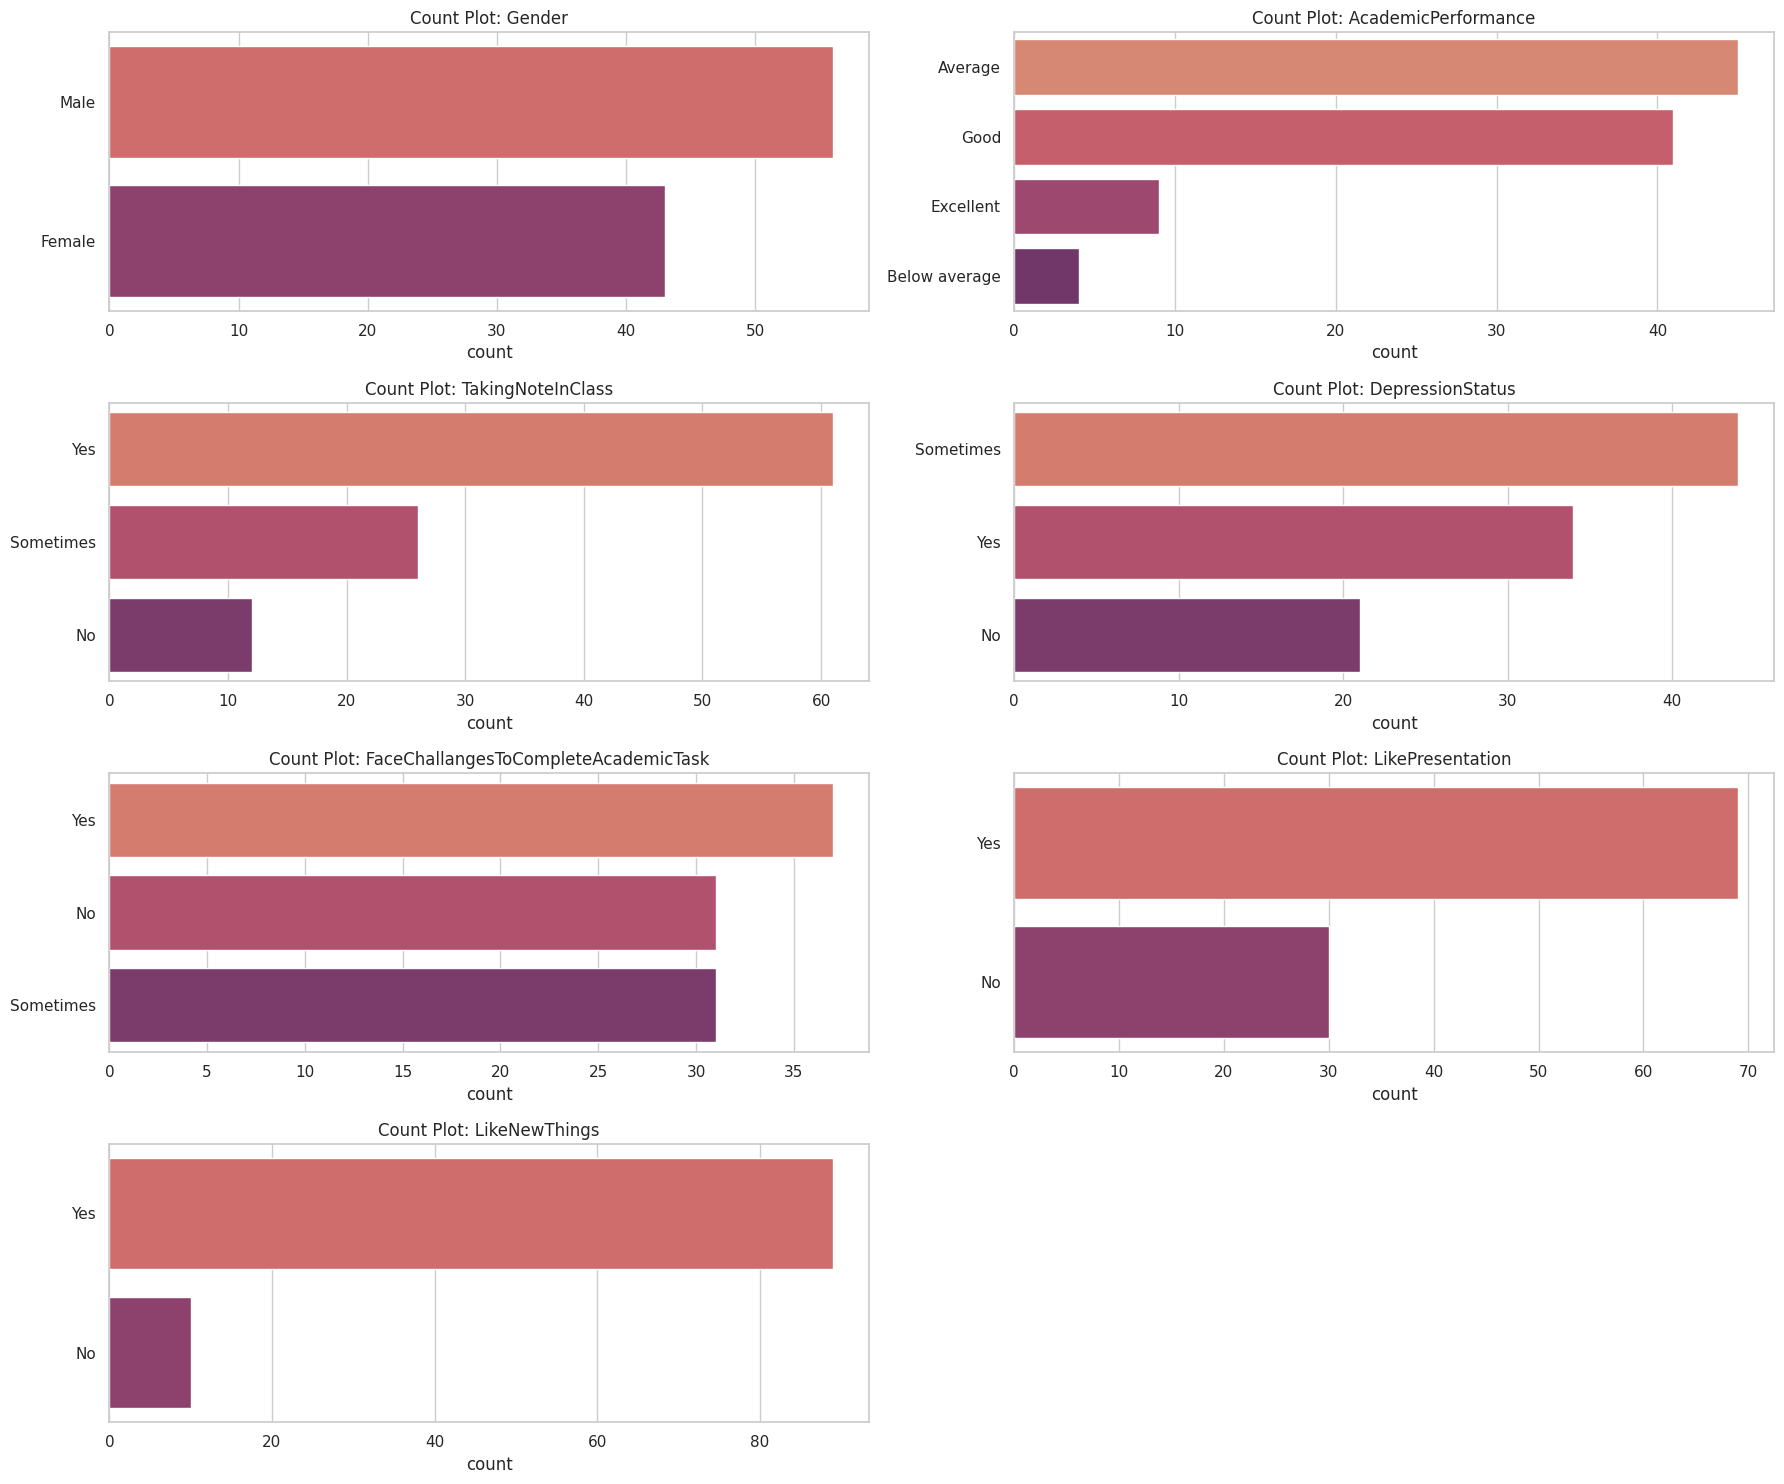


--- B. Distribusi Variabel Numerik ---


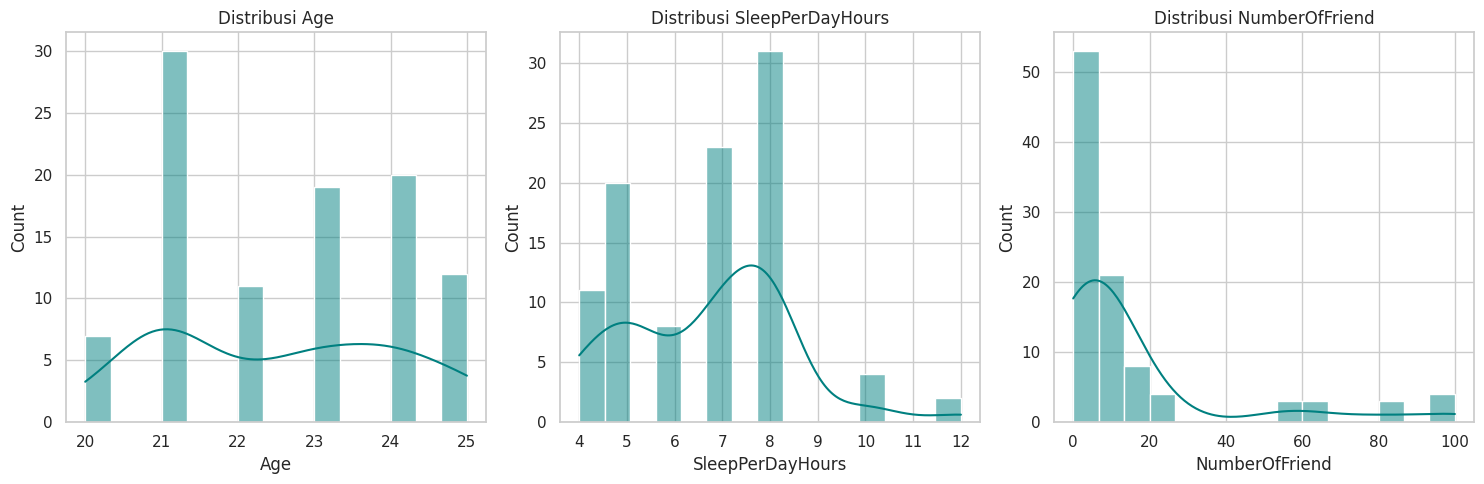


--- C. Matriks Korelasi (Kolom Numerik) ---


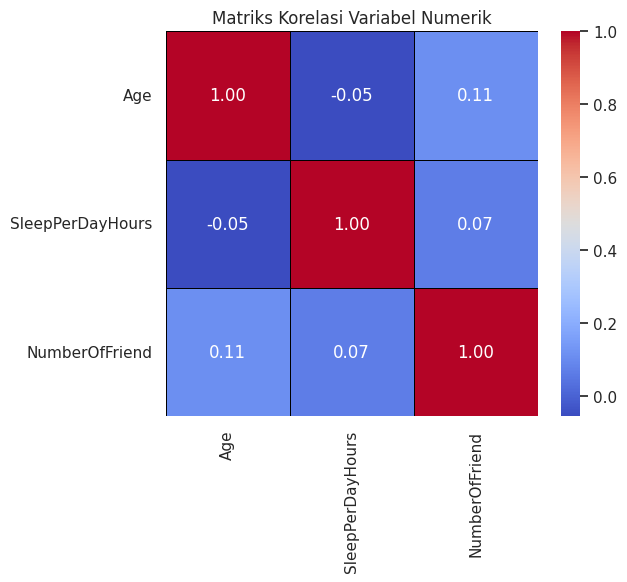

----------------------------------------------------------------------
## 5️⃣ DATA BERSIH SIAP DIPAKAI MODELLING & PENYIMPANAN
5 Baris Pertama Data Setelah Pembersihan:
   Age  Gender AcademicPerformance TakingNoteInClass DepressionStatus  \
0   23    Male             Average                No        Sometimes   
1   23    Male           Excellent         Sometimes              Yes   
2   24    Male             Average                No        Sometimes   
3   20  Female                Good               Yes        Sometimes   
4   24  Female             Average               Yes              Yes   

  FaceChallangesToCompleteAcademicTask LikePresentation  SleepPerDayHours  \
0                                  Yes              Yes                12   
1                                   No              Yes                 8   
2                            Sometimes               No                 8   
3                                  Yes               No                 5   
4      

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Atur gaya visualisasi
sns.set_style("whitegrid")

# --- 1. Memuat Dataset ---
# Pastikan Anda telah mengunggah file 'CSE_student_performances.csv' ke sesi Colab Anda.
file_path = 'CSE_student_performances.csv'
try:
    df = pd.read_csv(file_path)
    print("✅ DATASET BERHASIL DIMUAT")
    print("-" * 70)
except FileNotFoundError:
    print(f"❌ ERROR: File tidak ditemukan di path: {file_path}")
    # Anda bisa tambahkan instruksi untuk upload file di sini jika error
    exit()

# Mengubah nama kolom agar konsisten (menghilangkan spasi)
df.columns = df.columns.str.replace(' ', '')


# --- 2. Struktur Dataset (Shape, Info, Missing Values) ---
print("## 1️⃣ STRUKTUR DATASET")
print(f"Jumlah Baris (Observasi): {df.shape[0]}")
print(f"Jumlah Kolom (Fitur): {df.shape[1]}\n")

print("--- Tipe Data dan Non-Null Counts ---")
df.info()

print("\n--- Ringkasan Missing Values ---")
print(df.isnull().sum())
print("-" * 70)


# --- 3. Statistik Deskriptif ---
print("## 2️⃣ STATISTIK DESKRIPTIF")

print("\n--- Statistik Numerik (Age, SleepPerDayHours, NumberOfFriend) ---")
print(df.describe().T)

print("\n--- Statistik Kategorikal (Modus, Frekuensi, Unik) ---")
print(df.describe(include='object').T)
print("-" * 70)


# --- 4. Pembersihan Data (Handling Missing Values) ---
print("## 3️⃣ PEMBERSIHAN DATA (Missing Value)")

# Kolom yang memiliki Missing Value adalah 'NumberOfFriend' (1 missing value)
# Mengisi missing value dengan nilai Median
median_friends = df['NumberOfFriend'].median()
df['NumberOfFriend'].fillna(median_friends, inplace=True)

print(f"Missing Value di 'NumberOfFriend' diisi dengan Median: {median_friends}")

print("\nKonfirmasi Missing Values Setelah Pembersihan:")
print(df.isnull().sum())
print("Data sekarang tidak memiliki Missing Value.")
print("-" * 70)


# --- 5. Visualisasi Dasar ---
print("## 4️⃣ VISUALISASI DASAR")

# Identifikasi Kolom
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = ['Age', 'SleepPerDayHours', 'NumberOfFriend']

# A. Distribusi Variabel Kategorikal
print("\n--- A. Distribusi Variabel Kategorikal ---")
plt.figure(figsize=(18, 15))
for i, col in enumerate(categorical_cols):
    plt.subplot(4, 2, i + 1)
    sns.countplot(y=df[col], data=df, palette='flare', order=df[col].value_counts().index)
    plt.title(f'Count Plot: {col}', fontsize=12)
    plt.ylabel('')
plt.tight_layout()
plt.show()



# B. Distribusi Variabel Numerik
print("\n--- B. Distribusi Variabel Numerik ---")
plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i + 1)
    sns.histplot(df[col], kde=True, bins=15, color='teal')
    plt.title(f'Distribusi {col}', fontsize=12)
    plt.xlabel(col)
plt.tight_layout()
plt.show()



# C. Matriks Korelasi Numerik
print("\n--- C. Matriks Korelasi (Kolom Numerik) ---")
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, linecolor='black')
plt.title('Matriks Korelasi Variabel Numerik')
plt.show()

print("-" * 70)


# --- 6. Data Bersih Siap Dipakai Modelling dan Disimpan ---
print("## 5️⃣ DATA BERSIH SIAP DIPAKAI MODELLING & PENYIMPANAN")

# Tampilkan 5 baris pertama data setelah pembersihan
print("5 Baris Pertama Data Setelah Pembersihan:")
print(df.head())

# Tampilkan ringkasan data untuk konfirmasi
print("\nKonfirmasi Struktur Akhir Data:")
df.info()

# --- REVISI: Menyimpan DataFrame ke file CSV ---
output_file_name = 'cleaned_student_performances.csv'
df.to_csv(output_file_name, index=False) # index=False mencegah penulisan index DataFrame ke file CSV

print("\n---")
print(f"🎉 **Dataset sudah bersih dari missing value sederhana dan siap untuk *Modelling*.**")
print(f"✅ **File CSV baru telah disimpan dengan nama:** `{output_file_name}`")
print("Anda dapat mengunduhnya dari folder file di Google Colab.")
print("---")

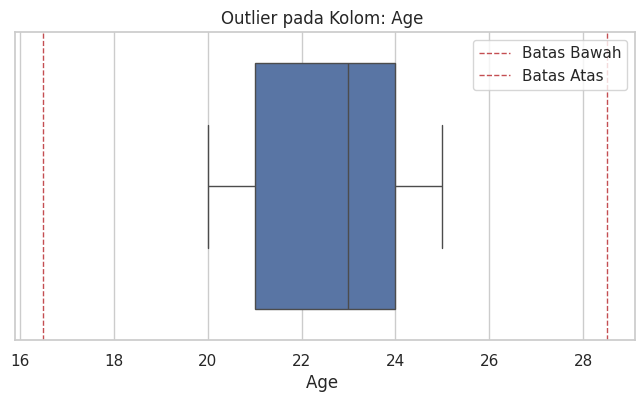


[HASIL IQR untuk Age ]
Q1 (25th Percentile): 21.00
Q3 (75th Percentile): 24.00
IQR: 3.00
Batas Bawah (Lower Bound): 16.50
Batas Atas (Upper Bound): 28.50
Tidak ditemukan outlier (berdasarkan metode IQR).
--------------------------------------------------


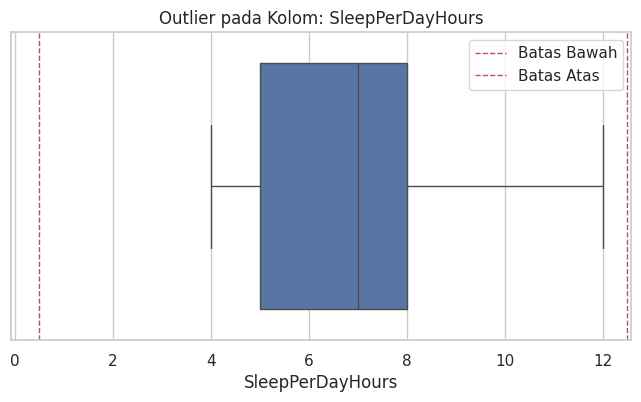


[HASIL IQR untuk SleepPerDayHours]
Q1 (25th Percentile): 5.00
Q3 (75th Percentile): 8.00
IQR: 3.00
Batas Bawah (Lower Bound): 0.50
Batas Atas (Upper Bound): 12.50
Tidak ditemukan outlier (berdasarkan metode IQR).
--------------------------------------------------


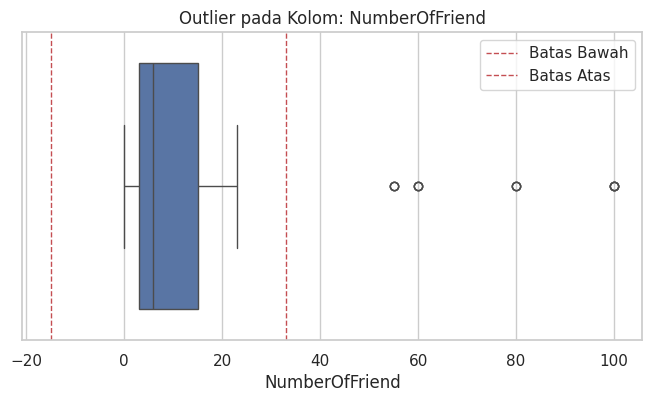


[HASIL IQR untuk NumberOfFriend]
Q1 (25th Percentile): 3.00
Q3 (75th Percentile): 15.00
IQR: 12.00
Batas Bawah (Lower Bound): -15.00
Batas Atas (Upper Bound): 33.00
Ditemukan 13 outlier:
[ 80.  60.  55. 100.  80.  60.  55. 100.  80.  60.  55. 100. 100.]
--------------------------------------------------


In [ ]:
for col in num_cols:

    # 1. Perhitungan Kuartil dan IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # Menentukan batas outlier
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # 2. Identifikasi Outlier
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    # 3. Visualisasi (Boxplot)
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Outlier pada Kolom: {col}")

    # Menambahkan anotasi batas pada plot (opsional, untuk visualisasi)
    plt.axvline(lower_bound, color='r', linestyle='--', linewidth=1, label='Batas Bawah')
    plt.axvline(upper_bound, color='r', linestyle='--', linewidth=1, label='Batas Atas')
    plt.legend()
    plt.show()

    # 4. Mencetak Hasil Perhitungan IQR
    print(f"\n[HASIL IQR untuk {col}]")
    print(f"Q1 (25th Percentile): {Q1:.2f}")
    print(f"Q3 (75th Percentile): {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Batas Bawah (Lower Bound): {lower_bound:.2f}")
    print(f"Batas Atas (Upper Bound): {upper_bound:.2f}")

    # Mencetak jumlah dan nilai outlier
    if not outliers.empty:
        print(f"Ditemukan {len(outliers)} outlier:")
        print(outliers[col].values)
    else:
        print("Tidak ditemukan outlier (berdasarkan metode IQR).")

    print("-" * 50)
